In [1]:
import pandas as pd
import numpy as np
import main
import matplotlib.pyplot as plt
import process as pc
import os

plt.style.use("best_style.mplstyle")

/home/etru7215/Documents/MvSR/mvsr_datasets/analysis/process.py:201: SyntaxWarning: invalid escape sequence '\l'
  latex_expr = latex_expr.replace("\left(", "(")


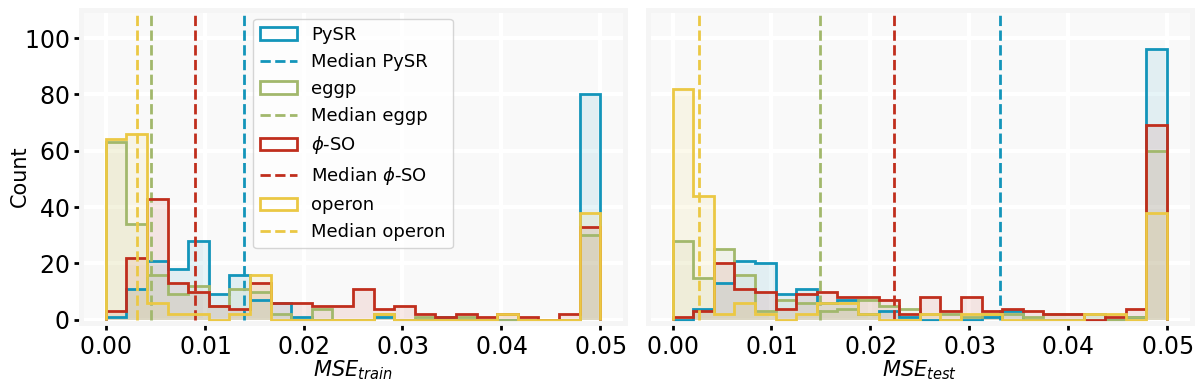

In [2]:
import seaborn as sns

colors = [k['color'] for k in list(plt.rcParams['axes.prop_cycle'])]
upper = 0.05
bins = np.linspace(0, upper, 25)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for bigidx, chi in enumerate(['chi2', 'chi2_test']):

    for idx, method in enumerate(pc.methods):
        distrib = []
        for dataset in pc.datasets:
            for config in pc.configs:
                distrib += list(pd.read_pickle(f"results/{method}/{dataset}_{config}.pkl")[chi].apply(max))
    
        distrib = np.array(distrib)
        median = np.nanmedian(distrib)
        distrib[distrib!=distrib] = upper
        distrib[distrib>upper] = upper


        if method == 'PhySO':
            method = '$\\phi$-SO'

        axes[bigidx].hist(distrib, bins=bins, alpha=.1, histtype='bar', linewidth=2, color=colors[idx])
        axes[bigidx].hist(distrib, bins=bins, label=method, alpha=1, histtype='step', linewidth=2, color=colors[idx])
        axes[bigidx].vlines(median, ymin=0, ymax=110, color=colors[idx], linestyles='dashed', linewidth=2, label=f"Median {method}")
    
    axes[bigidx].set_xlabel([f"$MSE_{{train}}$", f"$MSE_{{test}}$"][bigidx], labelpad=0, fontsize=15)
    axes[bigidx].set_ylim(-1, 110)

fig.text(-0.0, 0.55, 'Count', va='center', rotation='vertical', fontsize=15)
axes[0].legend(fontsize=13)
axes[1].tick_params(axis='y',which='both', left=False,labelleft=False)

fig.tight_layout(pad=1)


plt.savefig(f"analysis/plots/statistics.png", bbox_inches='tight')
plt.savefig(f"analysis/plots/statistics.pdf", bbox_inches='tight')


PySR : big_simple
eggp : big_simple
PhySO : big_simple
operon : big_simple


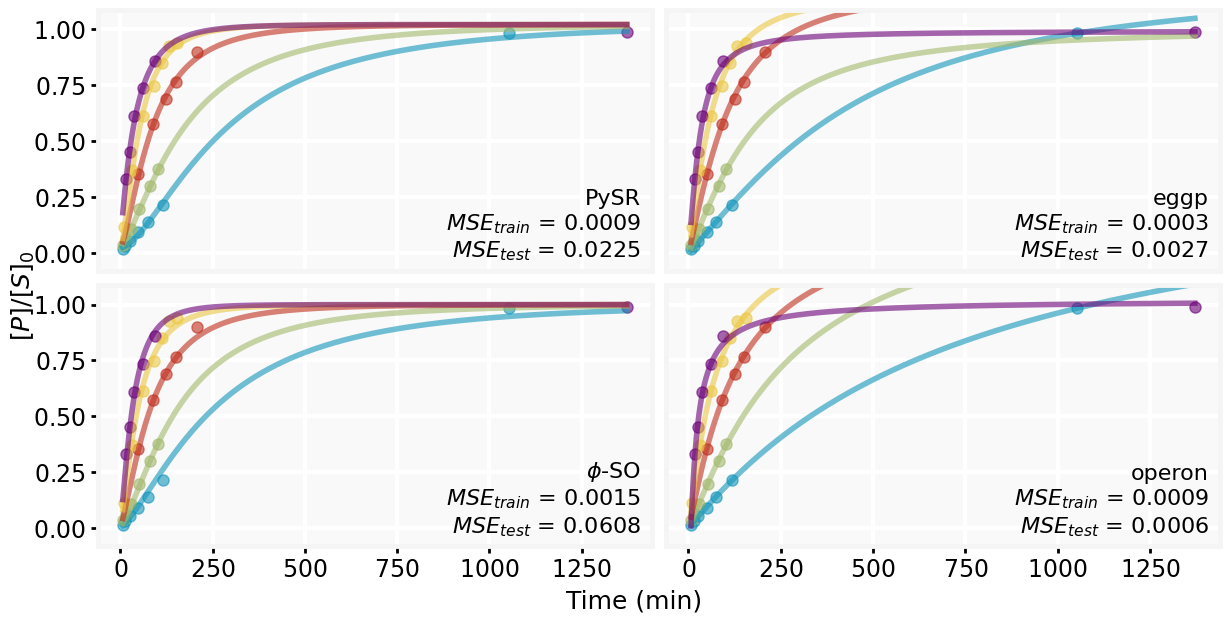

In [3]:
fig, axes = pc.plot_all_bests('biology', xlabel='Time (min)', ylabel='$[P]/[S]_0$', show_n=7)
plt.savefig("analysis/plots/biology_results.png", bbox_inches='tight')
plt.savefig("analysis/plots/biology_results.pdf", bbox_inches='tight')

PySR : big_simple
eggp : big_complex
PhySO : big_complex
operon : small_simple


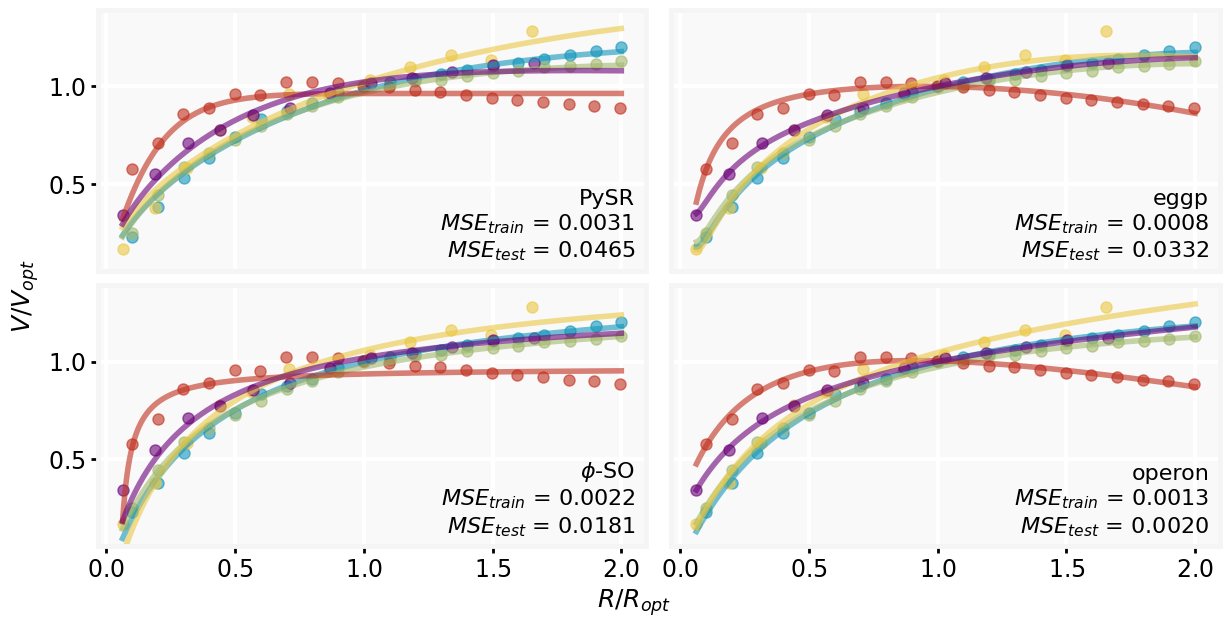

In [4]:
fig, axes = pc.plot_all_bests('galaxies', xlabel='$R/R_{opt}$', ylabel='$V/V_{opt}$',show_n=5)
plt.savefig("analysis/plots/galaxy_results.png", bbox_inches='tight')
plt.savefig("analysis/plots/galaxy_results.pdf", bbox_inches='tight')

PySR : small_simple
eggp : big_simple
PhySO : small_simple
operon : big_simple


<string>:1: RuntimeWarning: overflow encountered in exp
<string>:1: RuntimeWarning: invalid value encountered in sqrt
<string>:1: RuntimeWarning: invalid value encountered in sqrt
<string>:1: RuntimeWarning: invalid value encountered in sqrt
<string>:1: RuntimeWarning: invalid value encountered in sqrt
<string>:1: RuntimeWarning: invalid value encountered in sqrt


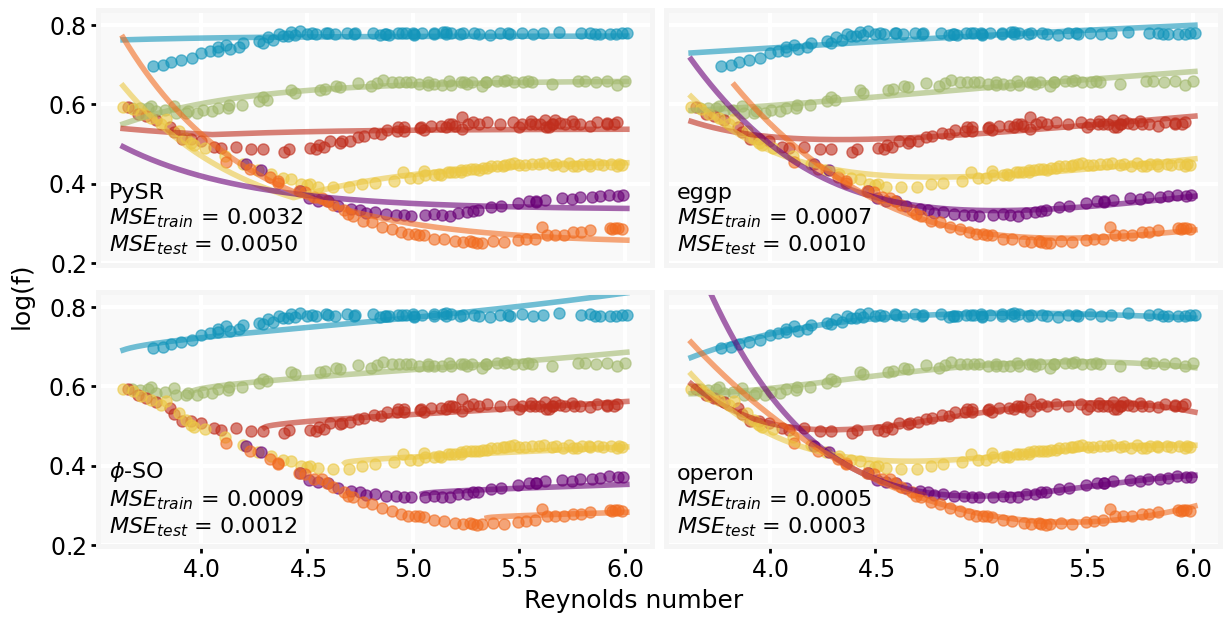

In [5]:
fig, axes = pc.plot_all_bests('fluid', xlabel='Reynolds number', ylabel='log(f)', show_n=6, horizontalalignment='left', method_pos=(0.02, 0.03))

plt.savefig("analysis/plots/fluid_results.png", bbox_inches='tight')
plt.savefig("analysis/plots/fluid_results.pdf", bbox_inches='tight')

PySR : big_simple
eggp : big_complex
PhySO : big_simple
operon : big_simple


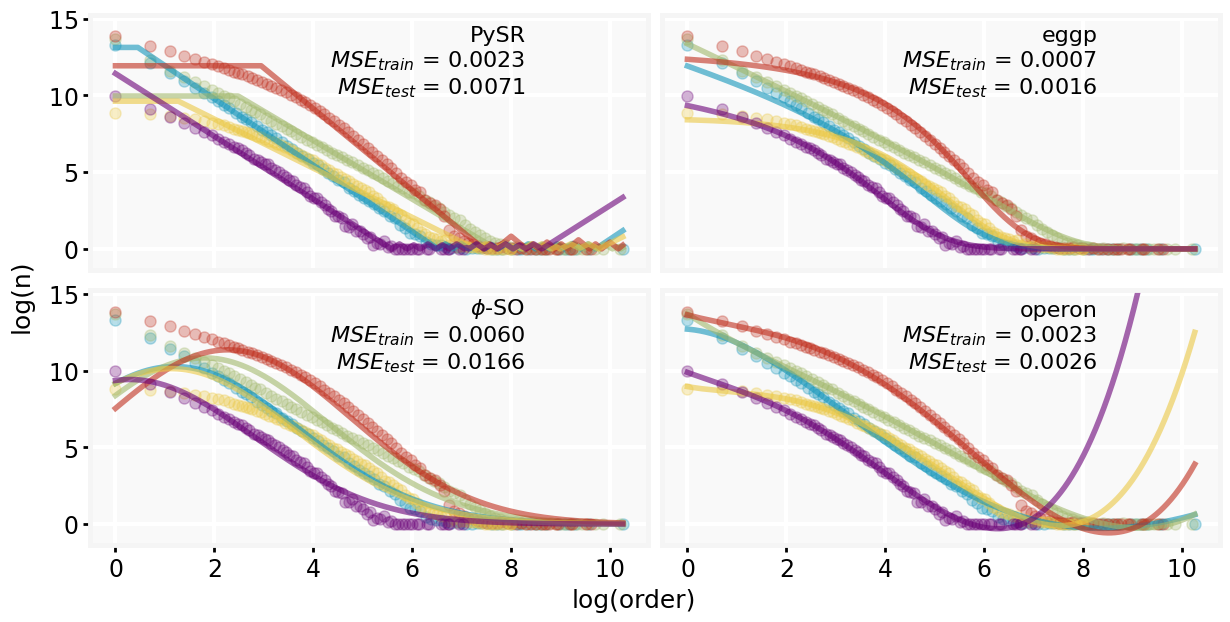

In [6]:
fig, axes = pc.plot_all_bests('graphs', xlabel='log(order)', ylabel='log(n)', show_n=5,
                           method_pos=(0.78, 0.67), scatter_alpha=0.3)
plt.savefig("analysis/plots/graph_results.png", bbox_inches='tight')
plt.savefig("analysis/plots/graph_results.pdf", bbox_inches='tight')

PySR : big_simple
eggp : big_complex
PhySO : big_complex
operon : big_simple


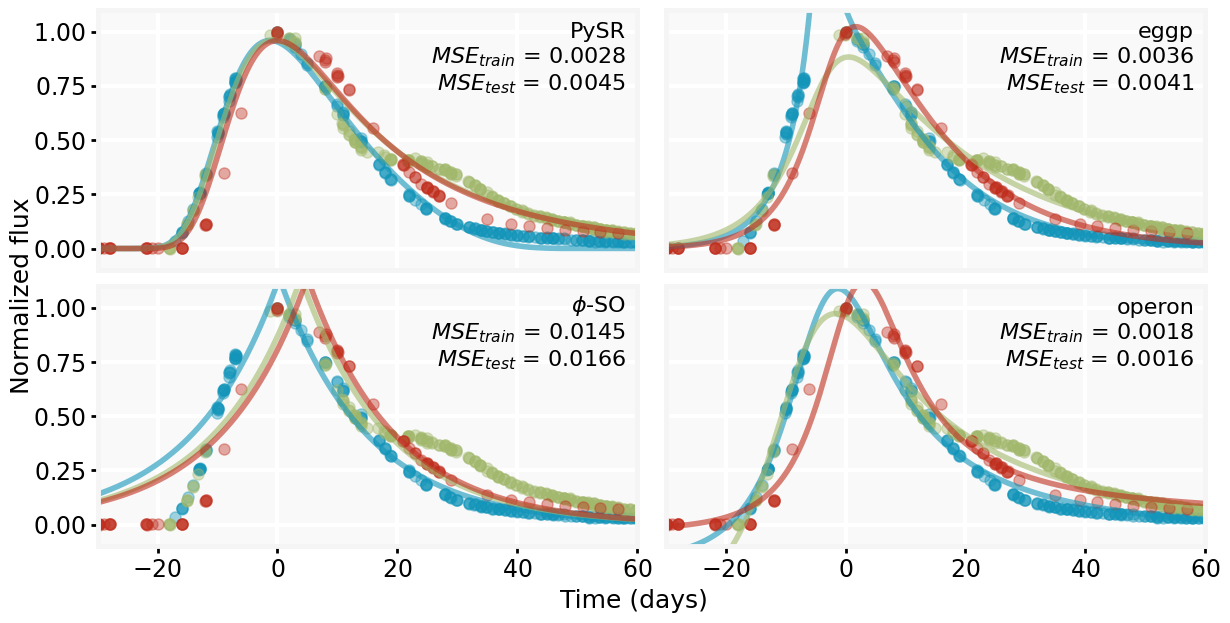

In [7]:
fig, axes = pc.plot_all_bests('supernovae', xlabel='Time (days)', ylabel='Normalized flux', show_n=3,
                           method_pos=(0.98, 0.67), scatter_alpha=0.4, xlim=(-30, 60))
plt.savefig("analysis/plots/supernovae_results.png", bbox_inches='tight')
plt.savefig("analysis/plots/supernovae_results.pdf", bbox_inches='tight')

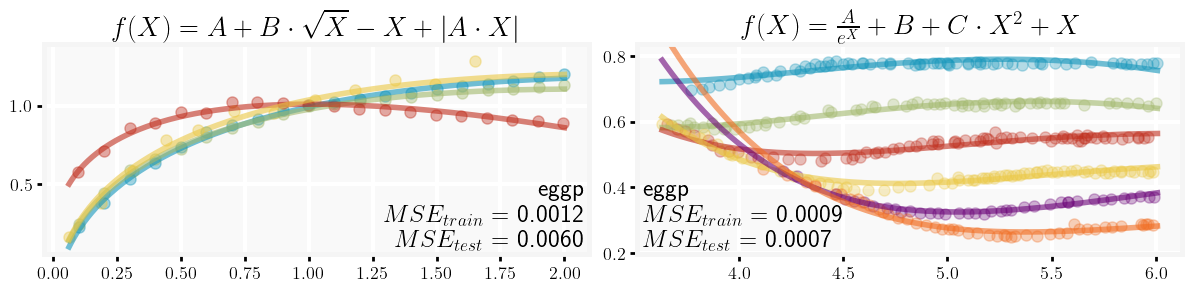

In [8]:
import matplotlib.pyplot as plt

plt.rcParams['text.usetex'] = True

datasets = ['galaxies', 'fluid', 'graphs']
methods = ['eggp', 'eggp', 'eggp']
hypers = ['small_simple', 'small_complex', 'big_complex']
expressions = [pc.summary_tables('expression')[datasets[i]].loc[hypers[i], methods[i]] for i in range(3)]
best_params = [pc.summary_tables('parameters')[datasets[i]].loc[hypers[i], methods[i]]for i in range(3)]
latexes = [pc.generate_latex(expressions[i]) for i in range(3)]
latexes[1] = latexes[1].replace('X \\cdot X', 'X^2')
chi2s = [pc.summary_tables('chi2')[datasets[i]].loc[hypers[i], methods[i]] for i in range(3)]
chi2s_test = [pc.summary_tables('chi2_test')[datasets[i]].loc[hypers[i], methods[i]] for i in range(3)]

fig, axes = plt.subplots(1,2,figsize=(12, 3),)

i=0

pc.plot_solution(axes.flatten()[i], datasets[i], main.make_function(expressions[i]),
                 best_params[i], show_n=4, title=latexes[i], scatter_alpha=0.4, xlim=None)
title1 = f"$f(X)={latexes[i]}$"
axes.flatten()[i].set_title(title1, fontsize=20)
axes.flatten()[i].text(.99, .01, f"{methods[i]}\n$MSE_{{train}}$ = {chi2s[i]:.4f}\n$MSE_{{test}}$ = {chi2s_test[i]:.4f}",
        transform=axes.flatten()[i].transAxes, horizontalalignment='right', verticalalignment='bottom', fontsize=18)

i=1
pc.plot_solution(axes.flatten()[i], datasets[i], main.make_function(expressions[i]),
                 best_params[i], show_n=6, title=None, scatter_alpha=0.3, xlim=None)
title2 = f"$f(X)={latexes[i]}$"
axes.flatten()[i].set_title(title2, fontsize=20)
axes.flatten()[i].text(.01, .01, f"{methods[i]}\n$MSE_{{train}}$ = {chi2s[i]:.4f}\n$MSE_{{test}}$ = {chi2s_test[i]:.4f}",
        transform=axes.flatten()[i].transAxes, horizontalalignment='left', verticalalignment='bottom', fontsize=18)


for i in range(2):
    axes.flatten()[i].xaxis.set_tick_params(labelsize=13)
    axes.flatten()[i].yaxis.set_tick_params(labelsize=13)

fig.tight_layout(pad=1)



plt.savefig("analysis/plots/halloffame.pdf", bbox_inches='tight')
plt.savefig("analysis/plots/halloffame.png", bbox_inches='tight')